# Mayo-Nancy NLP Analysis — v3
## Nancy Histological Index extraction from Turkish free-text pathology reports

**Dataset:** v7.xlsx  
**Changes from v2:**
- Panel B: Single pathologist (Cagatay) vs NLP — cleaner 2-bar comparison
- Panel C heatmap + Figure 2: Mayo 0-1 merged into Mayo 0
- All statistics still report both pathologists (kappa benchmark retained)

### How to run
- Put **v7.xlsx** in the same folder as this notebook
- **Kernel -> Restart & Run All**


## 1. Load packages

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    cohen_kappa_score, accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 110,
})

C_DEEP  = '#1B3B6F'
C_TEAL  = '#0E6E6E'
C_CORAL = '#E2705A'
C_AMBER = '#F4A340'
C_GREY  = '#4F5D75'
CMAP    = LinearSegmentedColormap.from_list(
    'teal', ['#F7FBFC', '#9BC7CF', C_TEAL, C_DEEP], N=256)

import sklearn, scipy
print(f"Python       : {__import__('sys').version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"scipy        : {scipy.__version__}")
print("\n All packages loaded")


Python       : 3.12.13
pandas       : 2.3.3
scikit-learn : 1.7.1
scipy        : 1.13.1

 All packages loaded


## 2. Load data

In [2]:
DATA_PATH  = "v7.xlsx"
SHEET_NAME = "mayo-tumhastalar.rtf"

df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f"Shape   : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns : {list(df.columns)}")
df.head(3)


Shape   : 832 rows x 19 columns
Columns : ['pt_number', 'national_id', 'endoscopy_date', 'patient_name', 'gender', 'birth_date', 'age', 'endoscopy_report', 'endoscopic_activity', 'mayo_score_classified', 'mayo_score', 'pathology_report', 'histologic_activity', 'nancy_index_burce', 'nancy_index_cagatay', 'modified_ide_score', 'histologic_ide_score', 'procedure', 'performing_physician']


,pt_number,national_id,endoscopy_date,patient_name,gender,birth_date,age,endoscopy_report,endoscopic_activity,mayo_score_classified,mayo_score,pathology_report,histologic_activity,nancy_index_burce,nancy_index_cagatay,modified_ide_score,histologic_ide_score,procedure,performing_physician
0,13,58504459268,2022-01-05,ŞAFAK TÜREMEZ,Erkek,1995-01-10,26,ÜLSERATİF KOLİT (AKTİF HASTALIK) MAYO 2,1.0,2,2,rapor yok,NaN,NaN,NaN,65400,38073,REKTO,NaN
1,14,35671038946,2022-01-06,ESRA OĞUZALP,Kadın,1972-10-28,49,"ÜLSERATİF KOLİT (MAYO SKORU 3, CİDDİ AKTİVİTELİ)",1.0,3,3,"KALIN BARSAK, SİGMOİD KOLON, REKTUM, ENDOSKOPİ...",1.0,4.0,4.0,65420,38078,KOLON,Doç. Dr. Bilger Çavuş
2,15,58198091898,2022-01-19,EREN EROL,Erkek,2001-02-02,20,TERMİNAL İLEUMDA NODÜLER GÖRÜNÜM (LENFOİD HİPE...,1.0,3,3,"I-İNCE BARSAK, TERMİNAL İLEUM, ENDOSKOPİK BİYO...",1.0,3.0,3.0,65608,38149,KOLON,Prof. Dr. Kadir Demir


## 3. Data overview

In [3]:
print("=== Missing values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== nancy_index_cagatay ===")
print(df['nancy_index_cagatay'].value_counts(dropna=False).sort_index())

print("\n=== mayo_score_classified ===")
print(df['mayo_score_classified'].astype(str).value_counts().sort_index())

print("\n=== endoscopic_activity ===")
print(df['endoscopic_activity'].value_counts(dropna=False))
print("  0 = endoscopic remission (Mayo 0-1)  |  1 = endoscopically active (Mayo 2-3)")

print("\n=== histologic_activity ===")
print(df['histologic_activity'].value_counts(dropna=False))
print("  0 = histologic remission (NHI 0-1)  |  1 = histologically active (NHI >= 2)")


=== Missing values ===
birth_date                1
endoscopy_report          1
endoscopic_activity       2
mayo_score_classified     2
mayo_score                2
histologic_activity      33
nancy_index_burce        33
nancy_index_cagatay      33
procedure                 9
performing_physician     16
dtype: int64

=== nancy_index_cagatay ===
nancy_index_cagatay
1.0    122
2.0    213
3.0    238
4.0    226
NaN     33
Name: count, dtype: int64

=== mayo_score_classified ===
mayo_score_classified
0       81
0-1     85
1      192
2      206
3      266
nan      2
Name: count, dtype: int64

=== endoscopic_activity ===
endoscopic_activity
1.0    472
0.0    358
NaN      2
Name: count, dtype: int64
  0 = endoscopic remission (Mayo 0-1)  |  1 = endoscopically active (Mayo 2-3)

=== histologic_activity ===
histologic_activity
1.0    677
0.0    122
NaN     33
Name: count, dtype: int64
  0 = histologic remission (NHI 0-1)  |  1 = histologically active (NHI >= 2)


## 4. Demographic summary

In [4]:
valid_age  = df['age'][df['age'] <= 100]
n_patients = df['national_id'].nunique()

print("=" * 50)
print("DEMOGRAPHIC SUMMARY")
print("=" * 50)
print(f"Total procedures  : {len(df)}")
print(f"Unique patients   : {n_patients}")
print(f"Age mean +/- SD   : {valid_age.mean():.1f} +/- {valid_age.std():.1f} years")
print(f"Age median [IQR]  : {valid_age.median():.0f} [{valid_age.quantile(0.25):.0f}-{valid_age.quantile(0.75):.0f}]")
male = (df['gender']=='Erkek').sum()
print(f"Male              : {male} ({100*male/len(df):.1f}%)")
print(f"Colonoscopy       : {(df['procedure']=='KOLON').sum()}")
print(f"Rectosigmoidoscopy: {(df['procedure']=='REKTO').sum()}")


DEMOGRAPHIC SUMMARY
Total procedures  : 832
Unique patients   : 501
Age mean +/- SD   : 44.3 +/- 16.1 years
Age median [IQR]  : 43 [31-58]
Male              : 481 (57.8%)
Colonoscopy       : 503
Rectosigmoidoscopy: 320


## 5. Nancy Histological Index criteria

**Reference:** Marchal-Bressenot A. et al. *Gut* 2017; 66:43-49

| Grade | Definition | Key discriminator |
|-------|-----------|-------------------|
| 0 | Normal mucosa | No inflammation |
| 1 | Chronic inflammatory infiltrate only | No active inflammation |
| 2 | Mild acute inflammatory infiltrate | Neutrophils/cryptitis; no crypt abscesses |
| 3 | Moderate-severe active inflammation | Crypt abscesses and/or basal plasmacytosis; no ulcer |
| 4 | Ulceration | Full-thickness epithelial loss |

**Pipeline rules:**
- Hierarchical: Grade 4 -> 3 -> 2 -> 1 -> 0
- Multi-segment reports: each segment graded independently -> **maximum** taken
- Polypectomy specimens: ulceration excluded
- Terminal ileum: excluded (Nancy applies to colonic UC only)
- Mayo 0-1 borderline entries: merged with Mayo 0 for analysis
  ("both represent deep/mucosal healing; separation reflects endoscopist uncertainty")


## 6. Text normalisation

In [13]:
def normalize(text):
    if not isinstance(text, str):
        return ""
    t = text.upper()
    t = t.replace('\u0130', 'I')
    t = t.translate(str.maketrans('UOCSGI', 'UOCSGI'))  # already ASCII after replace
    for src, dst in [('\u00dc','U'),('\u00d6','O'),('\u00c7','C'),
                     ('\u015e','S'),('\u011e','G')]:
        t = t.replace(src, dst)
    t = re.sub(r'\s+', ' ', t)
    return t.strip()

samples = ["ULSERASYON GOSTEREN AKTIF KRONIK KOLIT",
           "kript distorsiyonu gosteren kronik iltihap"]
for s in samples:
    print(f"  IN : {s}")
    print(f"  OUT: {normalize(s)}")
    print()


  IN : ULSERASYON GOSTEREN AKTIF KRONIK KOLIT
  OUT: ULSERASYON GOSTEREN AKTIF KRONIK KOLIT

  IN : kript distorsiyonu gosteren kronik iltihap
  OUT: KRIPT DISTORSIYONU GOSTEREN KRONIK ILTIHAP



## 7. Biopsy segment splitting

In [14]:
def split_segments(normalized_text):
    pattern = r'(?:^|\s)(?:I{1,4}V?|VI{0,3}|[0-9]+)[\-\)]\s*'
    segs = re.split(pattern, normalized_text)
    segs = [s.strip() for s in segs if s.strip()]
    return segs if segs else [normalized_text]


## 8. Nancy rules — regex patterns

Full pattern list -> **Supplementary Table S1**

In [16]:
# GRADE 4: Ulceration
RE_ULCER      = re.compile(r'\b(ULSER|EROZYON)')
RE_NEG_ULCER  = re.compile(r'ULSER\w*\s+(GOZLENMEDI|YOK|SAPTANMADI|IZLENMEDI)')

# GRADE 3: Severe active markers
RE_CRYPT_ABS  = re.compile(r'KRIPT\s*ABSE')
RE_BASAL_PL   = re.compile(r'BAZAL\s+(LENFOPLAZMASITOZ|PLAZMOSITOZ|LENFOPLAZM)')
RE_SEV_ACTIVE = re.compile(r'SIDDETLI\s+AKTIF')

# GRADE 2-3 discrimination
RE_ACTIVE     = re.compile(r'\bAKTIF\b')
RE_MILD       = re.compile(r'(HAFIF|MINIMAL|SEYREK|FOKAL|ODAKSAL)\s+(AKTIF|KRIPTIT)')

# GRADE 1: Chronic only
RE_CHRONIC    = re.compile(r'KRONIK\s+(ILTIHAP|INFLAMASYON|KOLIT|REKTIT)')

# GRADE 0: Normal
RE_NORMAL     = re.compile(r'\bNORMAL\b|BELIRGIN\s+DEGISIKLIK\s+YOK')

# Exclusion contexts
RE_POLYP      = re.compile(r'(PSODOPOLIP|PSEUDOPOLIP|POLIPEKTOMI|\bPOLIP\b|'
                            r'ADENOMATOZ|ADENOM|INFLAMATUAR POLIP|IMMUNREAKSIYON)')
RE_ILEUM      = re.compile(r'TERMINAL ILEUM')

print("Rules defined")


Rules defined


## 9. Classifier

In [17]:
def grade_segment(seg):
    is_polyp = bool(RE_POLYP.search(seg))
    is_ileum = bool(RE_ILEUM.search(seg))

    if (RE_ULCER.search(seg) and not RE_NEG_ULCER.search(seg)
            and not is_polyp and not is_ileum):
        return 4

    has_abs    = bool(RE_CRYPT_ABS.search(seg))
    has_basal  = bool(RE_BASAL_PL.search(seg))
    has_sev    = bool(RE_SEV_ACTIVE.search(seg))
    has_active = bool(RE_ACTIVE.search(seg))
    has_mild   = bool(RE_MILD.search(seg))

    if has_sev: return 3
    if has_abs and has_active and not has_mild: return 3
    if has_basal and has_active and not has_mild: return 3
    if has_abs and not is_polyp: return 3
    if has_active: return 2
    if RE_CHRONIC.search(seg) or 'ILTIHAP' in seg: return 1
    if RE_NORMAL.search(seg): return 0
    return 1


def classify_report(text):
    if not isinstance(text, str) or not text.strip():
        return np.nan
    segs   = split_segments(normalize(text))
    grades = [grade_segment(s) for s in segs]
    return max(grades) if grades else np.nan


print("Running NLP pipeline...")
df['nlp_nancy'] = df['pathology_report'].apply(classify_report)
print("Done")
print("\\nNLP prediction distribution:")
print(df['nlp_nancy'].value_counts(dropna=False).sort_index())


Running NLP pipeline...
Done
\nNLP prediction distribution:
nlp_nancy
1    152
2    225
3    258
4    197
Name: count, dtype: int64


## 10. Validation — both pathologists (reported in statistics, benchmark)

In [18]:
def evaluate(y_true, y_pred, name):
    mask = pd.notna(pd.Series(y_true)) & pd.notna(pd.Series(y_pred))
    yt = np.array(y_true)[mask].astype(int)
    yp = np.array(y_pred)[mask].astype(int)
    kq  = cohen_kappa_score(yt, yp, weights='quadratic')
    kl  = cohen_kappa_score(yt, yp, weights='linear')
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average='macro')
    print(f"\n{'='*55}")
    print(f"  {name}  (n = {len(yt)})")
    print(f"{'='*55}")
    print(f"  Quadratic-weighted kappa : {kq:.3f}")
    print(f"  Linear-weighted kappa    : {kl:.3f}")
    print(f"  Overall accuracy         : {acc:.3f}")
    print(f"  Macro-F1                 : {f1:.3f}")
    return {'n': len(yt), 'kappa_q': kq, 'kappa_l': kl, 'accuracy': acc, 'macro_f1': f1}

r1 = evaluate(df['nancy_index_burce'],   df['nlp_nancy'], 'NLP vs Pathologist 1 (Burce)')
r2 = evaluate(df['nancy_index_cagatay'], df['nlp_nancy'], 'NLP vs Pathologist 2 (Cagatay)')
r3 = evaluate(df['nancy_index_burce'],   df['nancy_index_cagatay'],
              'Pathologist 1 vs Pathologist 2 (human benchmark)')

pd.DataFrame([r1, r2, r3],
    index=['NLP vs Pat.1', 'NLP vs Pat.2', 'Pat.1 vs Pat.2']).round(3)



  NLP vs Pathologist 1 (Burce)  (n = 799)
  Quadratic-weighted kappa : 0.862
  Linear-weighted kappa    : 0.834
  Overall accuracy         : 0.854
  Macro-F1                 : 0.858

  NLP vs Pathologist 2 (Cagatay)  (n = 799)
  Quadratic-weighted kappa : 0.867
  Linear-weighted kappa    : 0.838
  Overall accuracy         : 0.856
  Macro-F1                 : 0.862

  Pathologist 1 vs Pathologist 2 (human benchmark)  (n = 799)
  Quadratic-weighted kappa : 0.990
  Linear-weighted kappa    : 0.990
  Overall accuracy         : 0.992
  Macro-F1                 : 0.991


,n,kappa_q,kappa_l,accuracy,macro_f1
NLP vs Pat.1,799,0.862,0.834,0.854,0.858
NLP vs Pat.2,799,0.867,0.838,0.856,0.862
Pat.1 vs Pat.2,799,0.990,0.990,0.992,0.991


## 11. Confusion matrix and per-class performance

In [19]:
# Reference: Pathologist 2 (Cagatay) — single pathologist going forward
mask   = df['nancy_index_cagatay'].notna() & df['nlp_nancy'].notna()
y_true = df.loc[mask, 'nancy_index_cagatay'].astype(int)
y_pred = df.loc[mask, 'nlp_nancy'].astype(int)
labels = sorted(set(y_true) | set(y_pred))

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm,
    index   = [f'Pathologist NHI {l}' for l in labels],
    columns = [f'NLP NHI {l}'         for l in labels])

print("Confusion matrix  (rows = pathologist reference, cols = NLP):")
display(cm_df)
print("\nPer-class performance:")
print(classification_report(y_true, y_pred, zero_division=0))
print("Per-grade accuracy:")
for g in labels:
    sub = (y_true == g)
    c   = (y_pred[sub] == g).sum()
    print(f"  NHI {g}: {c}/{sub.sum()} correct  ({100*c/sub.sum():.1f}%)")


Confusion matrix  (rows = pathologist reference, cols = NLP):


,NLP NHI 1,NLP NHI 2,NLP NHI 3,NLP NHI 4
Pathologist NHI 1,109,11,2,0
Pathologist NHI 2,3,178,28,4
Pathologist NHI 3,1,23,209,5
Pathologist NHI 4,6,13,19,188



Per-class performance:
              precision    recall  f1-score   support

           1       0.92      0.89      0.90       122
           2       0.79      0.84      0.81       213
           3       0.81      0.88      0.84       238
           4       0.95      0.83      0.89       226

    accuracy                           0.86       799
   macro avg       0.87      0.86      0.86       799
weighted avg       0.86      0.86      0.86       799

Per-grade accuracy:
  NHI 1: 109/122 correct  (89.3%)
  NHI 2: 178/213 correct  (83.6%)
  NHI 3: 209/238 correct  (87.8%)
  NHI 4: 188/226 correct  (83.2%)


## 12. Mayo score — numeric conversion

Borderline `mayo_score_classified = 0-1` entries are merged with Mayo 0 
(both represent mucosal/deep healing; separation reflects endoscopist uncertainty).

In [20]:
def mayo_to_num(v):
    if pd.isna(v): return np.nan
    # 0-1 -> 0.0 (merged with Mayo 0)
    mapping = {'0': 0.0, '0-1': 0.0, '1': 1.0, '2': 2.0, '3': 3.0}
    return mapping.get(str(v).strip(), np.nan)

df['mayo_num'] = df['mayo_score_classified'].apply(mayo_to_num)

print("Conversion (Mayo 0-1 merged into Mayo 0):")
print(pd.crosstab(df['mayo_score_classified'].astype(str),
                  df['mayo_num'].astype(str)))
print("\nFinal mayo_num distribution:")
print(df['mayo_num'].value_counts(dropna=False).sort_index())


Conversion (Mayo 0-1 merged into Mayo 0):
mayo_num               0.0  1.0  2.0  3.0  nan
mayo_score_classified                         
0                       81    0    0    0    0
0-1                     85    0    0    0    0
1                        0  192    0    0    0
2                        0    0  206    0    0
3                        0    0    0  266    0
nan                      0    0    0    0    2

Final mayo_num distribution:
mayo_num
0.0    166
1.0    192
2.0    206
3.0    266
NaN      2
Name: count, dtype: int64


## 13. Mayo-Nancy correlation (Spearman)

In [12]:
def spear(x, y, label):
    m    = pd.notna(x) & pd.notna(y)
    r, p = spearmanr(x[m], y[m])
    sig  = '< 0.001' if p < 0.001 else f'= {p:.4f}'
    print(f"  {label:<45s}  rho = {r:.3f}  (p {sig})")
    return r, p

print("Spearman correlations:\n")
rho_b, _ = spear(df['mayo_num'], df['nancy_index_burce'],   'Mayo vs Pathologist 1 (Burce)')
rho_c, _ = spear(df['mayo_num'], df['nancy_index_cagatay'], 'Mayo vs Pathologist 2 (Cagatay)')
rho_n, _ = spear(df['mayo_num'], df['nlp_nancy'],           'Mayo vs NLP Nancy')


Spearman correlations:

  Mayo vs Pathologist 1 (Burce)                  rho = 0.589  (p < 0.001)
  Mayo vs Pathologist 2 (Cagatay)                rho = 0.591  (p < 0.001)
  Mayo vs NLP Nancy                              rho = 0.521  (p < 0.001)


## 14. Clinical discordance analysis

`endoscopic_activity`: 0 = remission (Mayo 0-1) | 1 = active (Mayo 2-3)  
`histologic_activity`: 0 = remission (NHI 0-1)  | 1 = active (NHI >= 2)

In [21]:
m   = df['endoscopic_activity'].notna() & df['histologic_activity'].notna()
sub = df[m].copy()
N   = len(sub)

endo_rem        = (sub['endoscopic_activity'] == 0).sum()
hist_rem        = (sub['histologic_activity'] == 0).sum()
both_rem        = ((sub['endoscopic_activity'] == 0) & (sub['histologic_activity'] == 0)).sum()
endo_r_hist_act = ((sub['endoscopic_activity'] == 0) & (sub['histologic_activity'] == 1)).sum()

m2 = df['endoscopic_activity'].notna() & df['nancy_index_cagatay'].notna()
sub2 = df[m2]
endo_r_n      = (sub2['endoscopic_activity'] == 0).sum()
endo_r_severe = ((sub2['endoscopic_activity'] == 0) & (sub2['nancy_index_cagatay'] >= 3)).sum()

print("=" * 60)
print("CLINICAL DISCORDANCE ANALYSIS")
print("=" * 60)
print(f"  Total evaluable procedures      : {N}")
print()
print(f"  Endoscopic remission (Mayo 0-1) : {endo_rem:4d}  ({100*endo_rem/N:.1f}%)")
print(f"  Histologic remission (NHI 0-1)  : {hist_rem:4d}  ({100*hist_rem/N:.1f}%)")
print(f"  Both remissions combined        : {both_rem:4d}  ({100*both_rem/N:.1f}%)")
print()
print(f"  KEY FINDING:")
print(f"  Endoscopic remitters with persistent")
print(f"  histologic activity (NHI >= 2)  : {endo_r_hist_act}/{endo_rem} = {100*endo_r_hist_act/endo_rem:.1f}%")
print()
print(f"  Of these, moderate-severe (NHI >= 3):")
print(f"                                    {endo_r_severe}/{endo_r_n} = {100*endo_r_severe/endo_r_n:.1f}%")


CLINICAL DISCORDANCE ANALYSIS
  Total evaluable procedures      : 797

  Endoscopic remission (Mayo 0-1) :  345  (43.3%)
  Histologic remission (NHI 0-1)  :  120  (15.1%)
  Both remissions combined        :  114  (14.3%)

  KEY FINDING:
  Endoscopic remitters with persistent
  histologic activity (NHI >= 2)  : 231/345 = 67.0%

  Of these, moderate-severe (NHI >= 3):
                                    92/345 = 26.7%


## 15. Mayo x NHI cross-tabulation

In [22]:
ct = pd.crosstab(
    df.loc[m, 'mayo_num'],
    df.loc[m, 'nancy_index_cagatay'].astype(int),
    margins=True, margins_name='Total'
)
idx_map = {0.0:'Mayo 0 (incl. 0-1)', 1.0:'Mayo 1',
            2.0:'Mayo 2', 3.0:'Mayo 3', 'Total':'Total'}
ct.index   = [idx_map.get(i, i) for i in ct.index]
ct.columns = [f'NHI {c}' if c != 'Total' else c for c in ct.columns]
print("Mayo (rows) x NHI Pathologist 2 (columns):")
display(ct)


Mayo (rows) x NHI Pathologist 2 (columns):


,NHI 1,NHI 2,NHI 3,NHI 4,Total
Mayo 0 (incl. 0-1),81,49,15,14,159
Mayo 1,33,90,39,24,186
Mayo 2,4,46,93,54,197
Mayo 3,2,28,91,134,255
Total,120,213,238,226,797


## 16. Figure 1 — 4-panel main figure

**Changes:**
- **Panel B**: Single pathologist (Cagatay) vs NLP — 2 bars per grade, cleaner
- **Panel C**: Mayo 0-1 merged into Mayo 0 — 4 rows instead of 5


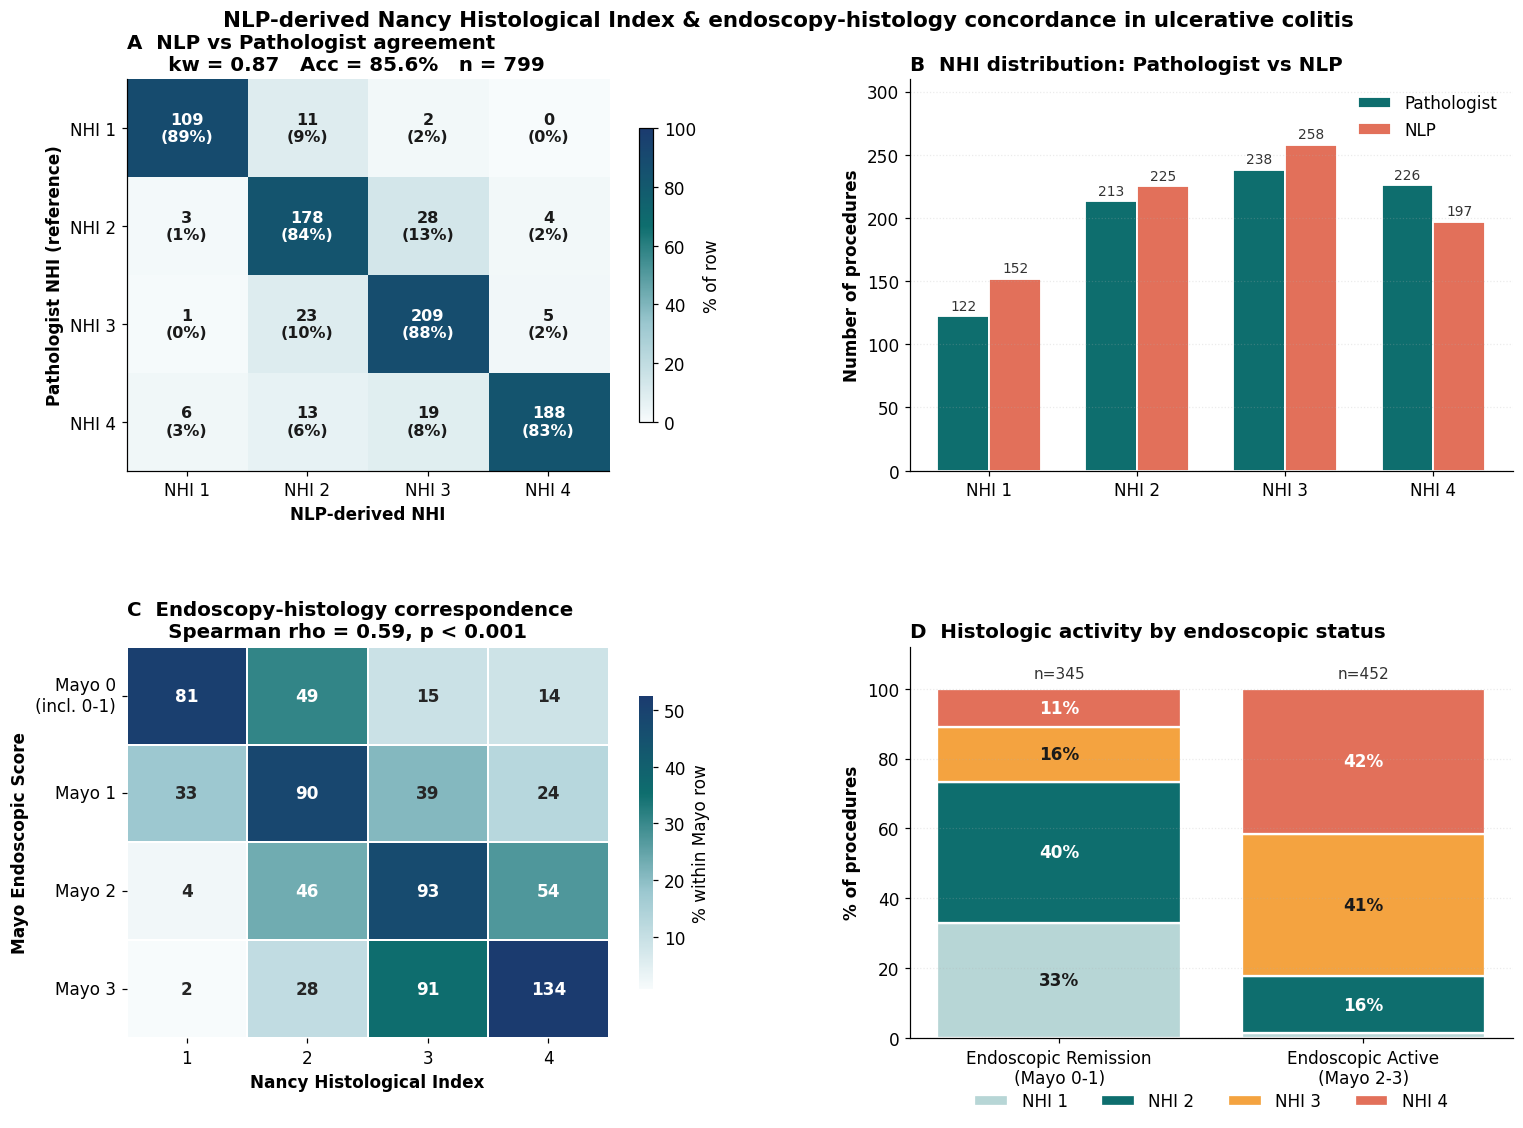


 figure1_main.png and .pdf saved


In [23]:
fig = plt.figure(figsize=(14, 10.5))
gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.30,
                       left=0.07, right=0.97, top=0.92, bottom=0.09)

# ── Panel A: Confusion matrix ────────────────────────────────────────────
axA = fig.add_subplot(gs[0, 0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
im = axA.imshow(cm_norm, cmap=CMAP, aspect='auto', vmin=0, vmax=100)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm[i, j]; p = cm_norm[i, j]
        col = 'white' if p > 45 else '#1a1a1a'
        axA.text(j, i, f"{v}\n({p:.0f}%)", ha='center', va='center',
                 fontsize=10.5, color=col, fontweight='bold')
axA.set_xticks(range(len(labels))); axA.set_yticks(range(len(labels)))
axA.set_xticklabels([f'NHI {g}' for g in labels])
axA.set_yticklabels([f'NHI {g}' for g in labels])
axA.set_xlabel('NLP-derived NHI', fontweight='bold')
axA.set_ylabel('Pathologist NHI (reference)', fontweight='bold')
kq  = cohen_kappa_score(y_true, y_pred, weights='quadratic')
acc = (y_true == y_pred).mean()
axA.set_title(f'A  NLP vs Pathologist agreement\n'
              f'      kw = {kq:.2f}   Acc = {acc:.1%}   n = {len(y_true)}', loc='left')
plt.colorbar(im, ax=axA, shrink=0.75, label='% of row')

# ── Panel B: Single pathologist vs NLP (2 bars per grade) ───────────────
axB = fig.add_subplot(gs[0, 1])
c_p  = [(df['nancy_index_cagatay'] == g).sum() for g in labels]
n_nl = [(df['nlp_nancy']           == g).sum() for g in labels]
x = np.arange(len(labels)); w = 0.35
axB.bar(x - w/2, c_p,  w, label='Pathologist', color=C_TEAL,  edgecolor='white', lw=1.2)
axB.bar(x + w/2, n_nl, w, label='NLP',         color=C_CORAL, edgecolor='white', lw=1.2)
for xi, vals in zip([x - w/2, x + w/2], [c_p, n_nl]):
    for px, v in zip(xi, vals):
        axB.text(px, v + 5, str(v), ha='center', fontsize=9, color='#333')
axB.set_xticks(x); axB.set_xticklabels([f'NHI {g}' for g in labels])
axB.set_ylabel('Number of procedures', fontweight='bold')
axB.set_title('B  NHI distribution: Pathologist vs NLP', loc='left')
axB.set_ylim(0, max(max(c_p), max(n_nl)) * 1.20)
axB.legend(frameon=False, loc='upper right')
axB.grid(axis='y', alpha=0.25, linestyle=':')

# ── Panel C: Mayo x NHI heatmap (Mayo 0-1 merged into Mayo 0) ───────────
axC = fig.add_subplot(gs[1, 0])
m_c  = df['mayo_num'].notna() & df['nancy_index_cagatay'].notna()
ct_h = pd.crosstab(df.loc[m_c, 'mayo_num'],
                   df.loc[m_c, 'nancy_index_cagatay'].astype(int))
# Mayo 0-1 already mapped to 0.0 in mayo_to_num — already merged
ct_h = ct_h.reindex(index=[0.0, 1.0, 2.0, 3.0], columns=labels, fill_value=0)
ct_pct = ct_h.div(ct_h.sum(axis=1), axis=0) * 100
sns.heatmap(ct_pct, annot=ct_h.values, fmt='d', cmap=CMAP, ax=axC,
            cbar_kws={'label': '% within Mayo row', 'shrink': 0.75},
            linewidths=1, linecolor='white',
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
axC.set_yticklabels(['Mayo 0\n(incl. 0-1)', 'Mayo 1', 'Mayo 2', 'Mayo 3'], rotation=0)
axC.set_xlabel('Nancy Histological Index', fontweight='bold')
axC.set_ylabel('Mayo Endoscopic Score', fontweight='bold')
rho_plot, _ = spearmanr(df.loc[m_c, 'mayo_num'], df.loc[m_c, 'nancy_index_cagatay'])
axC.set_title(f'C  Endoscopy-histology correspondence\n'
              f'      Spearman rho = {rho_plot:.2f}, p < 0.001', loc='left')

# ── Panel D: Endoscopic status breakdown ────────────────────────────────
axD = fig.add_subplot(gs[1, 1])
m_d   = df['endoscopic_activity'].notna() & df['nancy_index_cagatay'].notna()
sub_d = df[m_d]
strata_data, strata_lbls = [], []
for ea, lbl in [
    (0.0, 'Endoscopic Remission\n(Mayo 0-1)'),
    (1.0, 'Endoscopic Active\n(Mayo 2-3)')
]:
    ss  = sub_d[sub_d['endoscopic_activity'] == ea]; tot = len(ss)
    if tot == 0: continue
    strata_data.append(
        [100*(ss['nancy_index_cagatay']==g).sum()/tot for g in labels] + [tot])
    strata_lbls.append(lbl)
sdf    = pd.DataFrame(strata_data, columns=[f'NHI {g}' for g in labels] + ['n'])
colors = ['#B7D6D6', C_TEAL, C_AMBER, C_CORAL][:len(labels)]
bottom = np.zeros(len(sdf))
for col, cn in zip(colors, [f'NHI {g}' for g in labels]):
    axD.bar(strata_lbls, sdf[cn], bottom=bottom, label=cn,
            color=col, edgecolor='white', linewidth=1.5)
    for i, v in enumerate(sdf[cn]):
        if v >= 6:
            axD.text(i, bottom[i]+v/2, f"{v:.0f}%", ha='center', va='center',
                     fontsize=11, fontweight='bold',
                     color='white' if col in [C_TEAL, C_CORAL] else '#1a1a1a')
    bottom += sdf[cn].values
for i, nn in enumerate(sdf['n']):
    axD.text(i, 103, f"n={nn}", ha='center', fontsize=10, color='#333')
axD.set_ylim(0, 112)
axD.set_ylabel('% of procedures', fontweight='bold')
axD.set_title('D  Histologic activity by endoscopic status', loc='left')
axD.legend(frameon=False, loc='upper center', ncol=len(labels),
           bbox_to_anchor=(0.5, -0.10))
axD.grid(axis='y', alpha=0.25, linestyle=':')

fig.suptitle('NLP-derived Nancy Histological Index & endoscopy-histology concordance'
             ' in ulcerative colitis',
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('figure1_main.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure1_main.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print("\n figure1_main.png and .pdf saved")


## 17. Figure 2 — Mayo strata (4 bars: Mayo 0-1 merged)

Mayo 0-1 entries merged into Mayo 0. Vertical divider separates endoscopic remission from active disease.

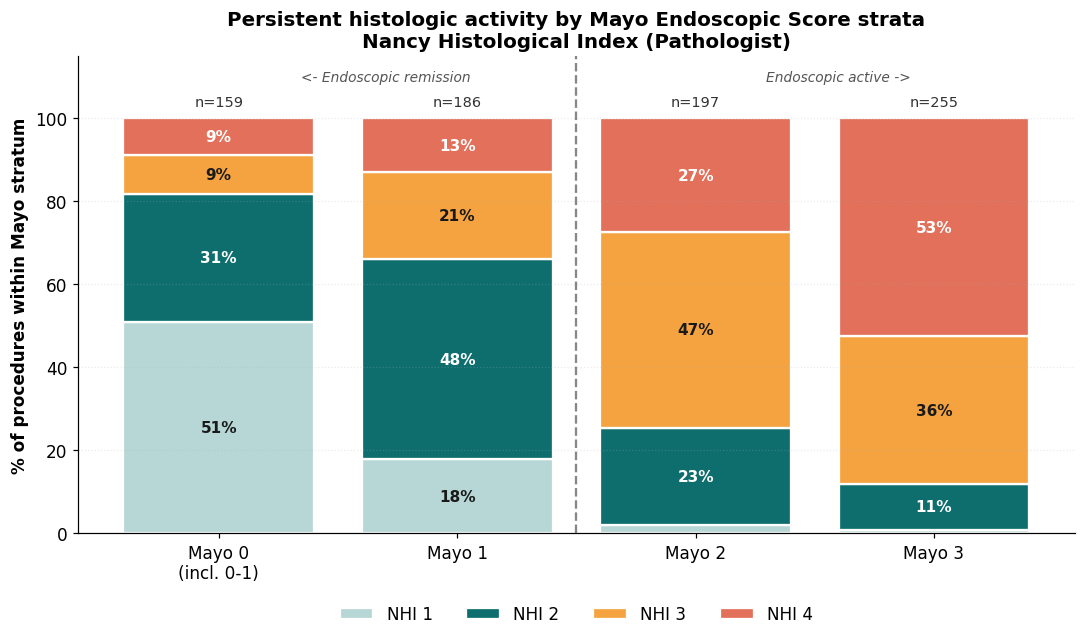

figure2_discordance.png and .pdf saved


In [26]:
fig2, ax = plt.subplots(figsize=(10, 6))
m_d2   = df['mayo_num'].notna() & df['nancy_index_cagatay'].notna()
sub_d2 = df[m_d2]

bar_data, bar_lbls = [], []
for mv, lbl in [(0.0,'Mayo 0\n(incl. 0-1)'), (1.0,'Mayo 1'),
                (2.0,'Mayo 2'), (3.0,'Mayo 3')]:
    ss  = sub_d2[sub_d2['mayo_num'] == mv]; tot = len(ss)
    if tot == 0: continue
    bar_data.append(
        [100*(ss['nancy_index_cagatay']==g).sum()/tot for g in labels] + [tot])
    bar_lbls.append(lbl)

sdf2    = pd.DataFrame(bar_data, columns=[f'NHI {g}' for g in labels] + ['n'])
colors  = ['#B7D6D6', C_TEAL, C_AMBER, C_CORAL][:len(labels)]
bottom  = np.zeros(len(sdf2))
for col, cn in zip(colors, [f'NHI {g}' for g in labels]):
    ax.bar(bar_lbls, sdf2[cn], bottom=bottom, label=cn,
           color=col, edgecolor='white', linewidth=1.5)
    for i, v in enumerate(sdf2[cn]):
        if v >= 6:
            ax.text(i, bottom[i]+v/2, f"{v:.0f}%", ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if col in [C_TEAL, C_CORAL] else '#1a1a1a')
    bottom += sdf2[cn].values
for i, nn in enumerate(sdf2['n']):
    ax.text(i, 103, f"n={nn}", ha='center', fontsize=9.5, color='#333')

# Divider: remission vs active
ax.axvline(x=1.5, color='#555', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(0.7, 109, '<- Endoscopic remission', ha='center', fontsize=9,
        color='#555', style='italic')
ax.text(2.6, 109, 'Endoscopic active ->', ha='center', fontsize=9,
        color='#555', style='italic')
ax.set_ylim(0, 115)
ax.set_ylabel('% of procedures within Mayo stratum', fontweight='bold')
ax.set_title('Persistent histologic activity by Mayo Endoscopic Score strata\n'
             'Nancy Histological Index (Pathologist)', fontweight='bold')
ax.legend(frameon=False, ncol=4, bbox_to_anchor=(0.5, -0.12), loc='upper center')
ax.grid(axis='y', alpha=0.25, linestyle=':')
plt.tight_layout()
plt.savefig('figure2_discordance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure2_discordance.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print("figure2_discordance.png and .pdf saved")


## 18. Error analysis (optional)

Uncomment to inspect specific confusion matrix cells.

In [24]:
def show_errors(true_grade, nlp_grade, n=5):
    mask_e = ((df['nancy_index_cagatay'] == true_grade) &
              (df['nlp_nancy']           == nlp_grade))
    errs = df[mask_e]
    print(f"\n=== Pathologist={true_grade}, NLP={nlp_grade}  ->  {len(errs)} cases ===")
    for idx, row in errs.head(n).iterrows():
        text = row['pathology_report']
        print(f"\n--- Row {idx} ---")
        print(text[:500] if isinstance(text, str) else 'N/A')
    return errs

# show_errors(true_grade=3, nlp_grade=2)
# show_errors(true_grade=2, nlp_grade=3)
# show_errors(true_grade=4, nlp_grade=3)


## 19. Save results

In [18]:
df.to_excel('nlp_results_full.xlsx', index=False)

clean = pd.DataFrame({
    'pt_number'            : df['pt_number'],
    'endoscopy_date'       : df['endoscopy_date'],
    'gender'               : df['gender'],
    'age_years'            : df['age'].where(df['age'] <= 100),
    'procedure'            : df['procedure'],
    'mayo_score_classified': df['mayo_score_classified'],
    'mayo_num'             : df['mayo_num'],
    'endoscopic_activity'  : df['endoscopic_activity'],
    'histologic_activity'  : df['histologic_activity'],
    'nhi_pathologist_1'    : df['nancy_index_burce'],
    'nhi_pathologist_2'    : df['nancy_index_cagatay'],
    'nhi_nlp'              : df['nlp_nancy'],
    'nlp_vs_pat2_match'    : (df['nlp_nancy'] == df['nancy_index_cagatay']).astype('Int64'),
    'pat1_vs_pat2_match'   : (df['nancy_index_burce'] == df['nancy_index_cagatay']).astype('Int64'),
})
clean.to_excel('nlp_results_clean.xlsx', index=False)
clean.to_csv('nlp_results_clean.csv', index=False)

print("Files saved:")
print("  nlp_results_full.xlsx    - full dataset + NLP predictions")
print("  nlp_results_clean.xlsx   - clean dataset for SPSS / Prism")
print("  nlp_results_clean.csv    - same data as CSV")
print("  figure1_main.png / .pdf  - 4-panel main figure")
print("  figure2_discordance.png  - 4-bar Mayo strata figure")


Files saved:
  nlp_results_full.xlsx    - full dataset + NLP predictions
  nlp_results_clean.xlsx   - clean dataset for SPSS / Prism
  nlp_results_clean.csv    - same data as CSV
  figure1_main.png / .pdf  - 4-panel main figure
  figure2_discordance.png  - 4-bar Mayo strata figure


## 20. Key numbers for the abstract

In [25]:
print("=" * 60)
print("KEY NUMBERS FOR ABSTRACT")
print("=" * 60)
print(f"\nCohort:")
print(f"  Total procedures  : {len(df)}")
print(f"  Unique patients   : {df['national_id'].nunique()}")
print(f"  Age mean +/- SD   : {valid_age.mean():.1f} +/- {valid_age.std():.1f} years")
print(f"  Male              : {(df['gender']=='Erkek').sum()} ({100*(df['gender']=='Erkek').sum()/len(df):.1f}%)")

print(f"\nNLP performance:")
print(f"  kw vs Pathologist 1 : {r1['kappa_q']:.3f}")
print(f"  kw vs Pathologist 2 : {r2['kappa_q']:.3f}")
print(f"  Accuracy            : {r2['accuracy']:.3f}")
print(f"  Macro-F1            : {r2['macro_f1']:.3f}")
print(f"  Human benchmark kw  : {r3['kappa_q']:.3f}")

print(f"\nCorrelation (Mayo 0-1 merged into Mayo 0):")
print(f"  Mayo-NHI Spearman rho: {rho_c:.3f}  (p < 0.001)")

m_sum = df['endoscopic_activity'].notna() & df['histologic_activity'].notna()
sub_s = df[m_sum]; N_s = len(sub_s)
er   = (sub_s['endoscopic_activity']==0).sum()
hr   = (sub_s['histologic_activity']==0).sum()
disc = ((sub_s['endoscopic_activity']==0) & (sub_s['histologic_activity']==1)).sum()
print(f"\nClinical discordance (n={N_s}):")
print(f"  Endoscopic remission : {er} ({100*er/N_s:.1f}%)")
print(f"  Histologic remission : {hr} ({100*hr/N_s:.1f}%)")
print(f"  Persistent histologic activity: {disc}/{er} = {100*disc/er:.1f}%")
print(f"  (endoscopic remitters with NHI >= 2)")


KEY NUMBERS FOR ABSTRACT

Cohort:
  Total procedures  : 832
  Unique patients   : 501
  Age mean +/- SD   : 44.3 +/- 16.1 years
  Male              : 481 (57.8%)

NLP performance:
  kw vs Pathologist 1 : 0.862
  kw vs Pathologist 2 : 0.867
  Accuracy            : 0.856
  Macro-F1            : 0.862
  Human benchmark kw  : 0.990

Correlation (Mayo 0-1 merged into Mayo 0):


NameError: name 'rho_c' is not defined

---
## Methods paragraph template

> *Pathology reports were pre-processed by conversion to upper case, removal of Turkish diacritics, and whitespace normalisation. Each report was segmented at biopsy-site markers (Roman numerals I-V) and graded independently; the procedure-level NHI was the maximum segment grade, excluding polypectomy specimens and terminal-ileum biopsies. Grades were assigned hierarchically using regular-expression pattern matching of pre-defined histologic descriptors (Supplementary Table S1). Two gastrointestinal pathologists independently assigned NHI grades to all reports; inter-rater agreement was near-perfect (kw = 0.99) and Pathologist 2 (C.X.) served as the reference standard. NLP pipeline agreement was assessed against both pathologists with quadratic-weighted Cohen's kappa. Mayo Endoscopic Score borderline entries (scored 0-1) were merged with Mayo 0 for analysis as both represent deep/mucosal healing. Spearman's rank correlation assessed the Mayo-NHI association. All analyses were performed in Python 3.11 (scikit-learn v1.x, SciPy v1.x).*
